Once you processed the high-energy data, here you can determine the proper scale.

__NOTE:__ the conversion is allowed for _PE, MeV_ to _MeV_.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image 
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# --- Notebook Parameters
TYPE = 'mc'
VERSION_TAG = "LPR_p2"

In [ ]:
# ------------------------------------
# DIRECTORIES, FILENAMES, PATHS & KEYS
# ------------------------------------
INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/'
INPUT_FILENAME = 'merged_tagged_runs_' + VERSION_TAG + '.h5' if TYPE == 'data' else 'merged_tagged_mc_calibration_lpr.h5'
INPUT_PATH = os.path.join(INPUT_DIR, INPUT_FILENAME)

EVT_KEY = 'Events'

# ----------------
# DETECTOR REGIONS
# ----------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# --------------------------------------
# REFERENCE PEAKS FOR ENERGY CALIBRATION
# --------------------------------------
ENERGY_UNITS, ENERGY_COL = None, None
KNOWN_PEAKS = None

KNOWN_PEAKS_PES = {
                        "511 keV":   {'real_MeV': 0.511,  'guess': 98e3,  'range': (88e3, 108e3)},
                        "583 keV":   {'real_MeV': 0.583,  'guess': 113e3, 'range': (103e3, 123e3)},
                        "727 keV":   {'real_MeV': 0.727,  'guess': 141e3, 'range': (131e3, 151e3)},
                        "860 keV":   {'real_MeV': 0.860,  'guess': 167e3, 'range': (157e3, 177e3)},
                        "DE Peak":   {'real_MeV': 1.592,  'guess': 313e3, 'range': (293e3, 333e3)},
                        "Tl Peak":   {'real_MeV': 2.615,  'guess': 515e3, 'range': (495e3, 535e3)}
}

if TYPE == 'data':
    KNOWN_PEAKS_MEV = {
                            "511 keV":   {'real_MeV': 0.511,  'guess': 0.52, 'range': (0.45, 0.59)},
                            "583 keV":   {'real_MeV': 0.583,  'guess': 0.60, 'range': (0.55, 0.65)},
                            "727 keV":   {'real_MeV': 0.727,  'guess': 0.75, 'range': (0.70, 0.80)},
                            "860 keV":   {'real_MeV': 0.860,  'guess': 0.90, 'range': (0.85, 0.95)},
                            "DE Peak":   {'real_MeV': 1.592,  'guess': 1.65, 'range': (1.55, 1.75)},
                            "Tl Peak":   {'real_MeV': 2.615,  'guess': 2.75, 'range': (2.65, 2.85)}
    }

elif TYPE == 'mc':
    KNOWN_PEAKS_MEV = {
                            "511 keV":   {'real_MeV': 0.511,  'guess': 0.50, 'range': (0.45, 0.55)},
                            "583 keV":   {'real_MeV': 0.583,  'guess': 0.58, 'range': (0.52, 0.64)},
                            # "727 keV":   {'real_MeV': 0.727,  'guess': 0.75, 'range': (0.70, 0.80)},  # Tl does not have this peak
                            "860 keV":   {'real_MeV': 0.860,  'guess': 0.86, 'range': (0.81, 0.91)},
                            "DE Peak":   {'real_MeV': 1.592,  'guess': 1.60, 'range': (1.50, 1.70)},
                            "Tl Peak":   {'real_MeV': 2.615,  'guess': 2.60, 'range': (2.50, 2.70)}
    }

### Helper Function

In [4]:
def calibrate_and_get_resolution( event_df     : pd.DataFrame
                                , known_peaks  : dict
                                , energy_col   : str
                                , energy_units : str
):
    """
    A full calibration pipeline that takes the energy column
    from the event dataframe and performs the following steps:
    1. Fits peaks in the uncalibrated energy spectrum, which can be in PE or MeV units.
    2. Determines the linear PE, MeV to MeV calibration.
    3. Applies the calibration.
    4. Re-fits the peaks in the calibrated MeV spectrum to find the resolution.
    """
    print(f"\n{'='*20} RUNNING {ENERGY_UNITS} → MeV CALIBRATION {'='*20}")
    initial_energies_df = event_df[energy_col]
    
    # ----- STAGE 01: Initial Fits ----- #
    print("\nSTAGE 01: Fitting uncalibrated peaks to find positions...")
    fig_init, axes_init = plt.subplots(int(np.ceil(len(known_peaks)/2)), 2, figsize=(16, 5*np.ceil(len(known_peaks)/2)))
    axes_init = axes_init.flatten()
    plt.suptitle(f'Initial Peak Fits', fontsize=25, y=0.94)

    initial_fit_results = []
    for i, (peak_name, props) in enumerate(known_peaks.items()):
        ax = axes_init[i]
        # --- Fitting
        popt, pcov, (hist_counts, hist_bins) = crudo.ff.fit_peak_crystal_ball(initial_energies_df, props['guess'], props['range'], bins=props.get('bins', 'auto'))
        # --- Plotting
        # Data
        ax.step(hist_counts, hist_bins, where='mid', label='Data')
        if popt is not None:
            # Fit
            fit_x = np.linspace(props['range'][0], props['range'][1], 300)
            ax.plot(fit_x, crudo.ff.crystal_ball_with_linear_bg(fit_x, *popt), 'r-', label='Fit')
            # Results
            mu, mu_err = popt[1], np.sqrt(pcov[1, 1])
            ax.text(0.025, 0.95, f'μ = ({mu:.4f} ± {mu_err:.4f}) {energy_units}', transform=ax.transAxes, va='top', fontsize=14)
            initial_fit_results.append({'name': peak_name, 'real_E_MeV': props['real_MeV'], 'uncalib_E': mu, 'uncalib_E_err': mu_err})
        # --- Styling
        ax.set_title(f'→ {peak_name}')
        ax.set_xlabel(f'Measured Energy ({energy_units})')
        ax.set_ylim(0.95*hist_bins.min(), 1.25*hist_bins.max())
        ax.legend(fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # ----- STAGE 02: Energy Scale (MeV vs. PE) ----- #
    fit_df = pd.DataFrame(initial_fit_results)
    if len(fit_df) < 2:
        print("Not enough successful fits to perform calibration. Aborting."); return None
    
    # Fit: Nominal Energy (MeV) = m * Uncalib. Energy (PE) + b
    calib_fit = linregress(fit_df['uncalib_E'], fit_df['real_E_MeV'])       # From here we can extract linear fit information
    m_calib, b_calib = calib_fit.slope, calib_fit.intercept
    calib_results = [{'m_cv': m_calib, 'm_err': calib_fit.stderr, 'b_cv': b_calib, 'b_err': calib_fit.intercept_stderr, 'r_value': calib_fit.rvalue}]
    print(f"\nStage 02: Calibration → Calibrated Energy (MeV) = {m_calib:.2e} * Uncalib. Energy ({energy_units}) + {b_calib:.4f}")

    # --- Plotting
    fig_calib, ax_calib = plt.subplots(figsize=(7, 5))
    # Data
    ax_calib.errorbar(fit_df['uncalib_E'], fit_df['real_E_MeV'], xerr=fit_df['uncalib_E_err'], fmt='o', lw=1.0, label='Fitted Peaks')
    # Fit
    x_fit = np.array([0, fit_df['uncalib_E'].max() * 1.1]); y_fit = m_calib * x_fit + b_calib
    ax_calib.plot(x_fit, y_fit, 'b--', label=f'Fit')
    # --- Styling
    ax_calib.set_xlabel(f'Uncalib. Peak Energy ({energy_units})')
    ax_calib.set_ylabel('Real Peak Energy (MeV)')
    ax_calib.legend(fontsize=12)
    ax_calib.grid(True)
    plt.show()

    # ----- STAGE 03: Apply Calibration ----- #
    print(f"\nStage 03: Applying calibration, going from {energy_units} to MeV...")
    calibrated_energies_df = m_calib * initial_energies_df + b_calib
    
    # ----- STAGE 04: Final Fits in MeV ----- #
    print("\nStage 04: Computing final energy resolution...")
    fig_final, axes_final = plt.subplots(int(np.ceil(len(known_peaks)/2)), 2, figsize=(16, 5*np.ceil(len(known_peaks)/2)))
    axes_final = axes_final.flatten()
    fig_final.suptitle(f'Final Resolution Fits (in MeV)', fontsize=25, y=0.94)

    final_resolution_results = []
    for i, (peak_name, props) in enumerate(known_peaks.items()):
        ax = axes_final[i]
        # --- Fitting
        real_E = props['real_MeV']
        calib_range = (real_E - 0.05, real_E + 0.05)    # Define fit range in calibrated MeV
        popt, pcov, (hist_counts, hist_bins) = crudo.ff.fit_peak_crystal_ball(calibrated_energies_df, real_E, calib_range, bins=props.get('bins', 'auto'))
        # --- Plotting
        # Data
        ax.step(hist_counts, hist_bins, where='mid', label='Data')
        if popt is not None:
            # Fit
            fit_x = np.linspace(calib_range[0], calib_range[1], 300)
            ax.plot(fit_x, crudo.ff.crystal_ball_with_linear_bg(fit_x, *popt), 'r-', label='Fit')
            # Results
            mu, sigma = popt[1], abs(popt[2])
            mu_err, sigma_err = np.sqrt(pcov[1, 1]), np.sqrt(pcov[2, 2])
            res_cv  = 2.355 * sigma / mu * 100
            res_err = res_cv * np.sqrt((sigma_err / sigma) ** 2 + (mu_err / mu) ** 2) if sigma > 0 else np.nan
            ax.text(0.025, 0.95, f'μ = ({mu:.4f} ± {mu_err:.4f}) MeV\nR(%) = {res_cv:.2f} ± {res_err:.2f}', transform=ax.transAxes, va='top', fontsize=14)
            final_resolution_results.append({'peak': peak_name, 'resolution_(FWHM)': res_cv, 'resolution_error': res_err})
        # --- Styling         
        ax.set_title(f'→ {peak_name}')
        ax.set_xlabel('Calibrated Energy (MeV)')
        ax.set_ylim(0.95*hist_bins.min(), 1.25*hist_bins.max())
        ax.legend(fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    return pd.DataFrame(calib_results), pd.DataFrame(final_resolution_results)

### Load Processed Data

In [7]:
MERGED_DF = pd.read_hdf(INPUT_PATH, key=EVT_KEY)
MERGED_DF

,event,global_event,time,isotope,volume,double_e,region,nS1,nS2,n_cluster,...,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,0,0,1.403882e+06,Tl208,PORT_1a,True,fiducial,1,1,1,...,468.0,676.407688,550.0,113.0,10000.0,412496.0,130.875,10751.0,513493.218750,14370.492188
1,1,1,3.768631e+06,Tl208,PORT_1a,False,tube,1,1,1,...,249.0,333.076721,525.0,55.0,10000.0,159583.0,98.425,5255.0,666483.625000,5489.101074
2,2,2,4.564927e+06,Tl208,PORT_1a,False,anode,1,1,1,...,179.0,342.969833,575.0,35.0,10000.0,198132.0,29.575,19978.0,46490.390625,7220.463379
3,3,3,6.753959e+06,Tl208,PORT_1a,False,tube,1,2,3,...,335.0,507.693007,550.0,71.0,10025.0,19042.0,29.450,1849.0,425483.062500,670.840576
4,3,3,6.753959e+06,Tl208,PORT_1a,False,tube,1,2,3,...,335.0,411.642709,550.0,71.0,10025.0,236672.0,131.225,7883.0,848489.625000,7804.173340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204571,4999022,130997,9.998045e+12,Tl208,PORT_1a,False,tube,1,2,3,...,271.0,372.852861,575.0,60.0,10000.0,40656.0,50.375,2576.0,609482.187500,1242.203003
204572,4999023,130998,9.998047e+12,Tl208,PORT_1a,False,tube,1,1,1,...,208.0,350.395322,425.0,39.0,10000.0,132060.0,44.225,6416.0,243489.921875,5364.290039
204573,4999024,130999,9.998049e+12,Tl208,PORT_1a,True,tube,1,1,1,...,684.0,1069.626724,525.0,155.0,10000.0,576357.0,145.075,14200.0,369487.156250,22211.998047
204574,4999025,131000,9.998052e+12,Tl208,PORT_1a,False,fiducial,1,2,2,...,222.0,391.254722,475.0,51.0,10000.0,12179.0,17.725,1787.0,171480.187500,233.101456


# Fiducial Electrons

After selecting just electron-like events, we first perform the $nS1 = nS2 = 1$ selection cut and plot spatial distributions as a check.

## Pulse Multiplicity

In [10]:
# --- Electron-like --- #
if TYPE == 'data':  electron_mask = (MERGED_DF['particle'] == 'electron')
elif TYPE == 'mc': 	electron_mask = None  # For MC all events are electron-like

ELECTRON_DF = MERGED_DF[electron_mask].copy() if electron_mask is not None else MERGED_DF.copy()

# --- nS1 = nS2 = 1 --- #
# This is an event-level dataframe as there is no peak multiplicity
pulse_mask = (ELECTRON_DF['nS1'] == 1) & (ELECTRON_DF['nS2'] == 1)
EVENT_DF = ELECTRON_DF[pulse_mask].copy()
EVENT_DF

,event,global_event,time,isotope,volume,double_e,region,nS1,nS2,n_cluster,...,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,0,0,1.403882e+06,Tl208,PORT_1a,True,fiducial,1,1,1,...,468.0,676.407688,550.0,113.0,10000.0,412496.0,130.875,10751.0,5.134932e+05,14370.492188
1,1,1,3.768631e+06,Tl208,PORT_1a,False,tube,1,1,1,...,249.0,333.076721,525.0,55.0,10000.0,159583.0,98.425,5255.0,6.664836e+05,5489.101074
2,2,2,4.564927e+06,Tl208,PORT_1a,False,anode,1,1,1,...,179.0,342.969833,575.0,35.0,10000.0,198132.0,29.575,19978.0,4.649039e+04,7220.463379
6,5,5,1.019016e+07,Tl208,PORT_1a,False,fiducial,1,1,1,...,220.0,296.450029,525.0,45.0,10000.0,172837.0,56.175,8380.0,6.514812e+05,5005.333008
9,7,7,1.507262e+07,Tl208,PORT_1a,False,tube,1,1,1,...,252.0,279.521325,475.0,58.0,10000.0,131858.0,60.350,6623.0,1.089492e+06,4574.898926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204561,4999016,130991,9.998032e+12,Tl208,PORT_1a,False,tube,1,1,2,...,253.0,345.667660,450.0,49.0,10025.0,187906.0,97.500,7648.0,6.234878e+05,6345.623047
204562,4999017,130992,9.998035e+12,Tl208,PORT_1a,False,tube,1,1,1,...,295.0,348.909825,475.0,63.0,10000.0,145534.0,84.375,4640.0,9.354978e+05,5715.884277
204565,4999019,130994,9.998040e+12,Tl208,PORT_1a,False,tube,1,1,1,...,462.0,671.980201,550.0,107.0,10000.0,311811.0,149.125,8144.0,5.014866e+05,11928.406250
204572,4999023,130998,9.998047e+12,Tl208,PORT_1a,False,tube,1,1,1,...,208.0,350.395322,425.0,39.0,10000.0,132060.0,44.225,6416.0,2.434899e+05,5364.290039


### Spatial Distributions

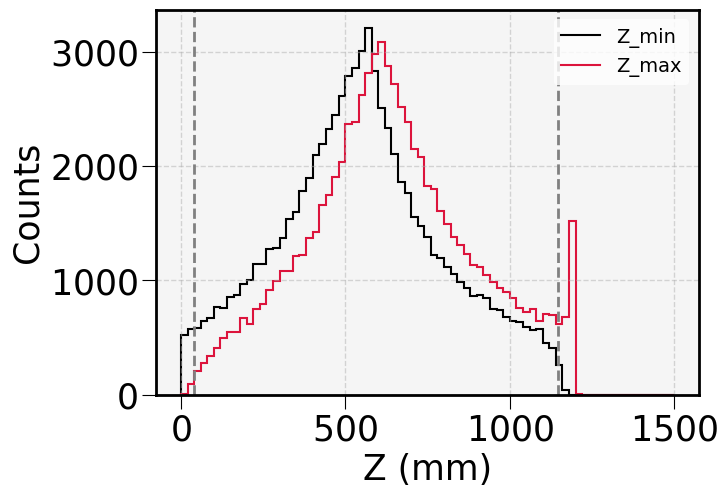

In [11]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

# ----- Define the Binning ----- #
_, Z_edges = np.histogram(EVENT_DF['Z_bary'], bins=n_bins, range=(0, 1500))

for i, var in enumerate(['Z_min', 'Z_max']):

        Z_counts, _ = np.histogram(EVENT_DF[var], bins=Z_edges)

        # ----- Plotting ----- #
        plt.stairs(Z_counts, Z_edges, label=f'{var}',
                   fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Z-limits
plt.axvline(x=Z_LOW, c='grey', ls='--')
plt.axvline(x=Z_UP, c='grey', ls='--')
        
# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper right', fontsize=14)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

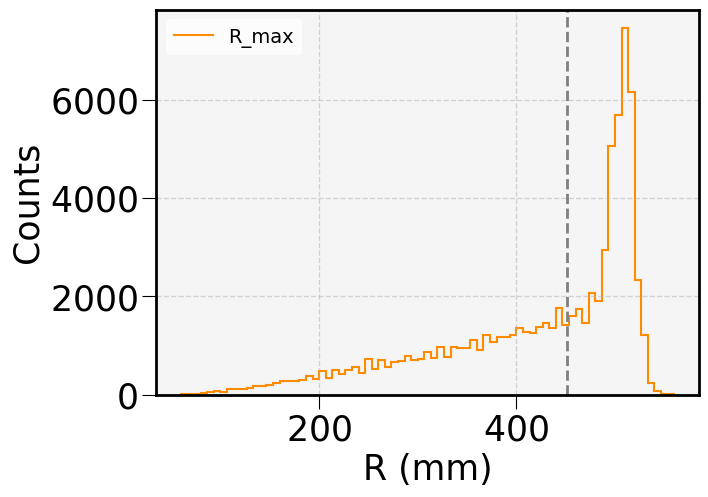

In [12]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

R_counts, R_edges = np.histogram(EVENT_DF['R_max'], bins=n_bins)
# ----- Plotting ----- #
plt.stairs(R_counts, R_edges, label='R_max',
           fill=False, lw=1.5, ec=crudo.pt.hist_colors[2])

# R-limit
plt.axvline(x=R_UP, c='grey', ls='--')
        
# ----- Styling ----- #
plt.xlabel('R (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper left', fontsize=14)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

## Fiducial Volume

In [13]:
fiducial_mask = (EVENT_DF['region'] == 'fiducial')
FIDU_EVT_DF = EVENT_DF[fiducial_mask].copy()
FIDU_EVT_DF

,event,global_event,time,isotope,volume,double_e,region,nS1,nS2,n_cluster,...,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,0,0,1.403882e+06,Tl208,PORT_1a,True,fiducial,1,1,1,...,468.0,676.407688,550.0,113.0,10000.0,412496.0,130.875,10751.0,5.134932e+05,14370.492188
6,5,5,1.019016e+07,Tl208,PORT_1a,False,fiducial,1,1,1,...,220.0,296.450029,525.0,45.0,10000.0,172837.0,56.175,8380.0,6.514812e+05,5005.333008
11,9,9,1.860971e+07,Tl208,PORT_1a,False,fiducial,1,1,1,...,338.0,408.024403,550.0,82.0,10000.0,228538.0,92.075,9780.0,8.884926e+05,6981.797363
20,14,14,2.912170e+07,Tl208,PORT_1a,False,fiducial,1,1,1,...,861.0,1130.799920,675.0,212.0,10000.0,703259.0,260.600,14341.0,7.044870e+05,28482.609375
22,17,16,3.449770e+07,Tl208,PORT_1a,False,fiducial,1,1,1,...,261.0,285.244361,550.0,60.0,10000.0,205870.0,100.400,6657.0,1.126483e+06,6068.231934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204539,4998022,130974,9.996045e+12,Tl208,PORT_1a,False,fiducial,1,1,1,...,456.0,647.150325,450.0,105.0,10000.0,360477.0,90.475,12693.0,5.484877e+05,11732.637695
204548,4999006,130981,9.998013e+12,Tl208,PORT_1a,False,fiducial,1,1,2,...,628.0,777.231263,425.0,136.0,10000.0,513608.0,241.400,7103.0,8.324850e+05,19950.839844
204555,4999011,130986,9.998024e+12,Tl208,PORT_1a,False,fiducial,1,1,1,...,787.0,1251.350283,625.0,159.0,10000.0,762855.0,226.075,14289.0,3.404887e+05,31153.101562
204556,4999012,130987,9.998025e+12,Tl208,PORT_1a,False,fiducial,1,1,1,...,231.0,389.859744,525.0,58.0,10000.0,256776.0,85.675,9605.0,2.404830e+05,8026.145508


# Energy Analysis

How does the energy look?

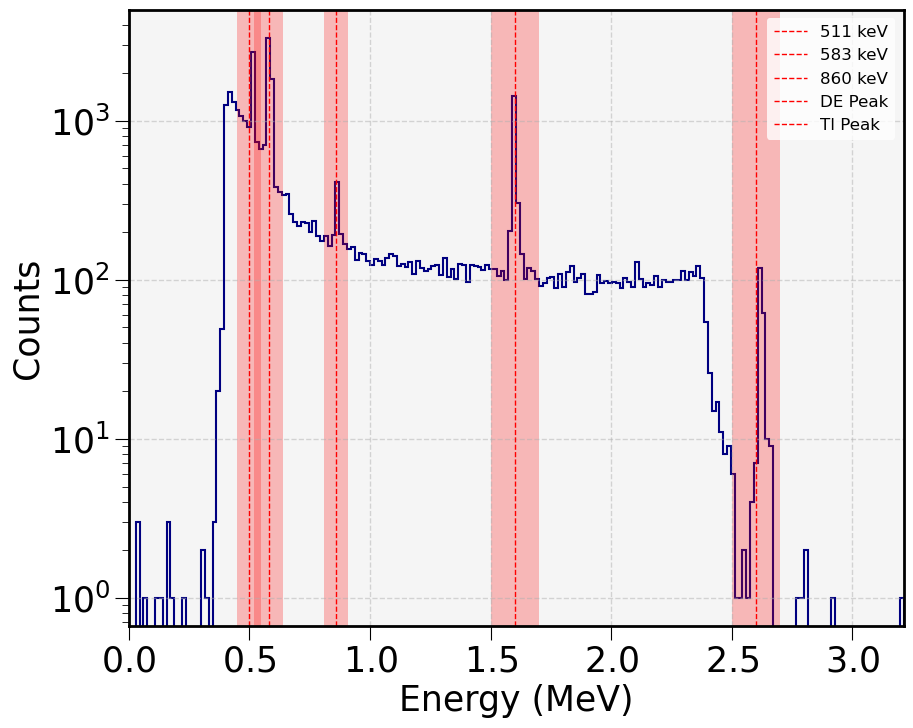

In [22]:
# First, we check which energy column is in the dataframe
if 'E_evt_pe' in FIDU_EVT_DF.columns:
    ENERGY_UNITS, ENERGY_COL = 'PE', 'E_evt_pe'
    KNOWN_PEAKS = KNOWN_PEAKS_PES
elif 'E_evt_mev' in FIDU_EVT_DF.columns:
    ENERGY_UNITS, ENERGY_COL = 'MeV', 'E_evt_mev'
    KNOWN_PEAKS = KNOWN_PEAKS_MEV

# ----- Plotting ----- #
n_bins = 200

E_counts, E_edges = np.histogram(FIDU_EVT_DF[ENERGY_COL], bins=n_bins)

plt.stairs(E_counts, E_edges,
           fill=False, lw=1.5, ec=crudo.pt.hist_colors[5])

# Reference peaks
for peak_name, peak_info in KNOWN_PEAKS.items():
    plt.axvline(x=peak_info['guess'], c='red', ls='--', lw=1.0, label=peak_name)
    plt.axvspan(peak_info['range'][0], peak_info['range'][1], color='red', ec=None, alpha=0.25)
        
# ----- Styling ----- #
plt.xlabel(f'Energy ({ENERGY_UNITS})')
plt.xlim(0, E_edges[-1])
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3) if ENERGY_UNITS == 'PE' else (0, 0))
plt.legend(loc='upper right', fontsize=12)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

### Execution


==================== RUNNING MeV → MeV CALIBRATION ====================

STAGE 01: Fitting uncalibrated peaks to find positions...


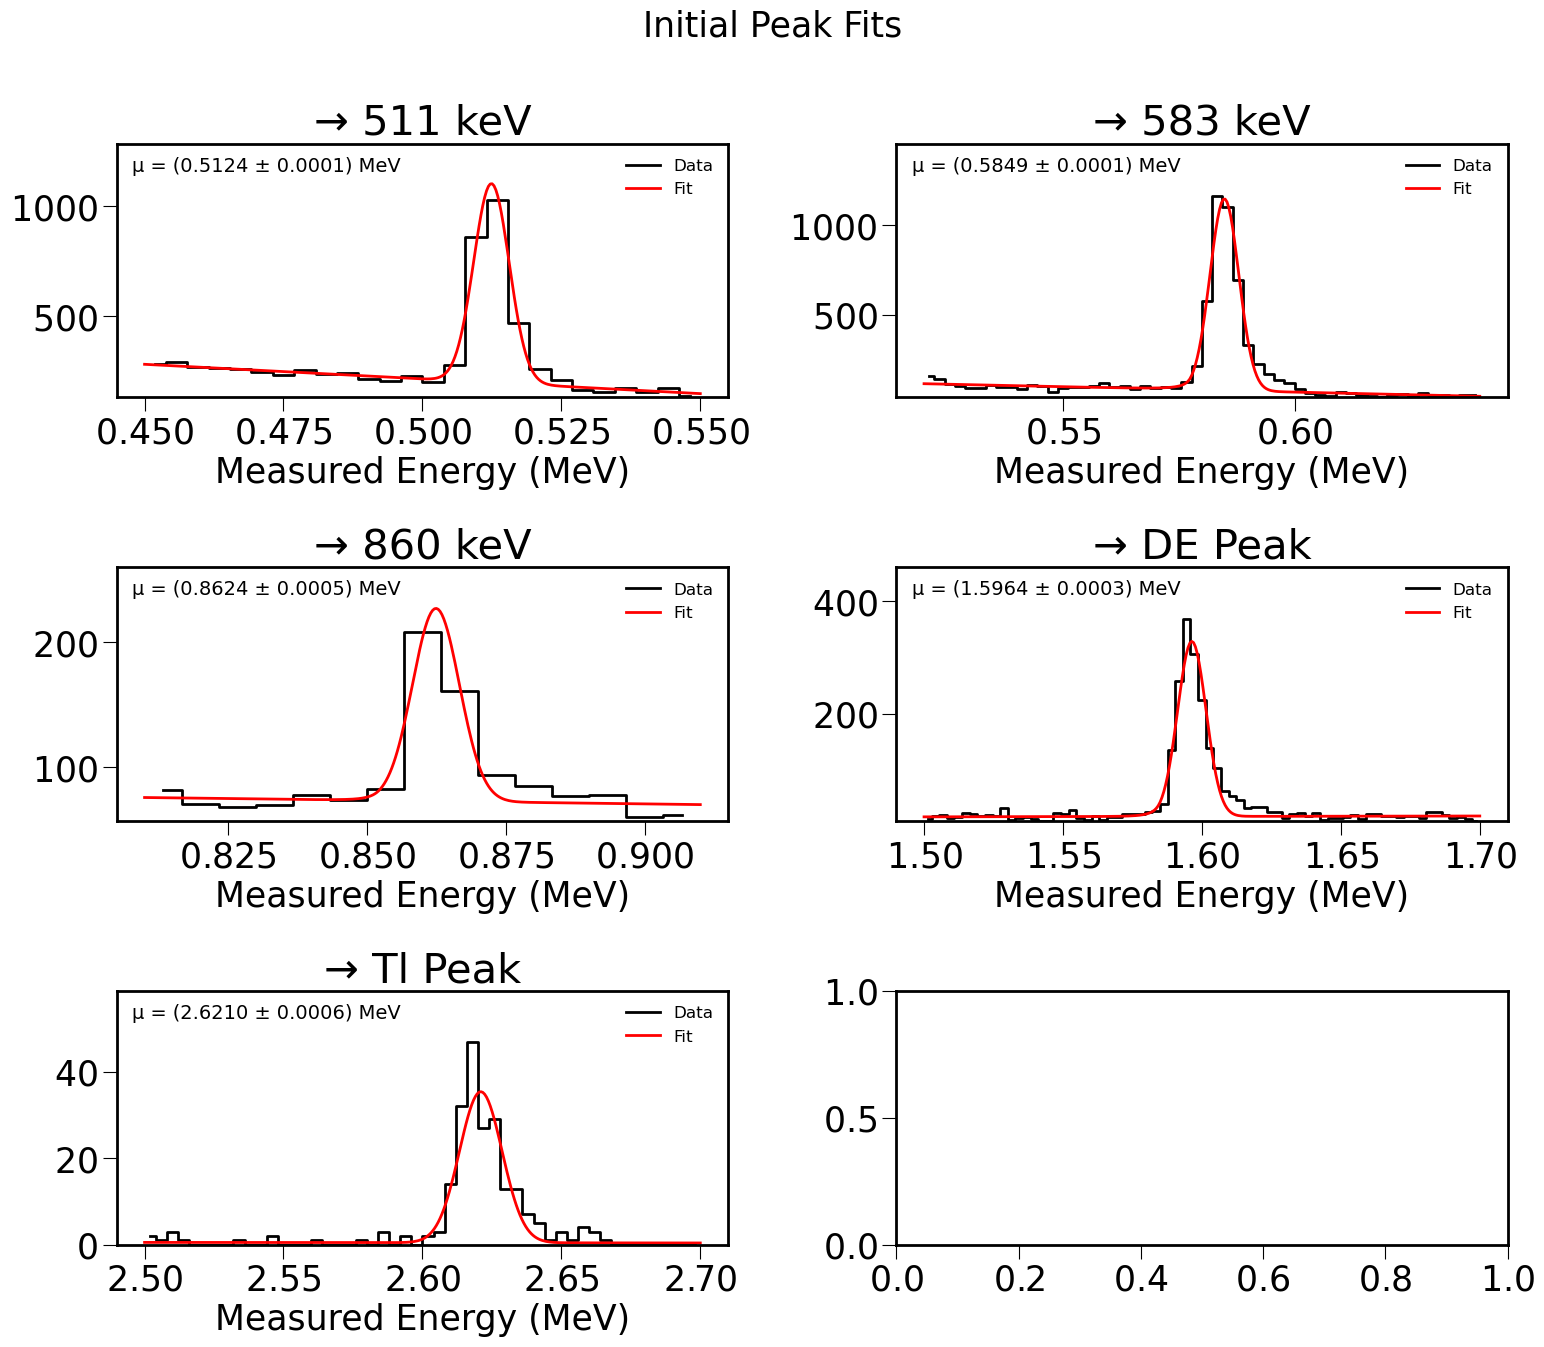


Stage 02: Calibration → Calibrated Energy (MeV) = 9.98e-01 * Uncalib. Energy (MeV) + -0.0006


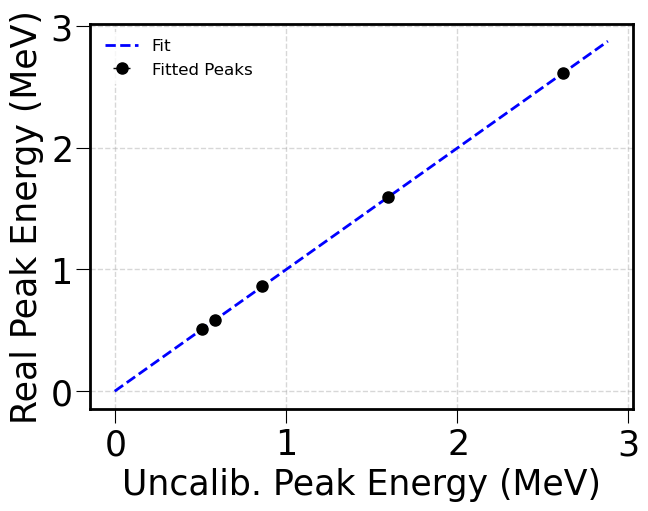


Stage 03: Applying calibration, going from MeV to MeV...

Stage 04: Computing final energy resolution...


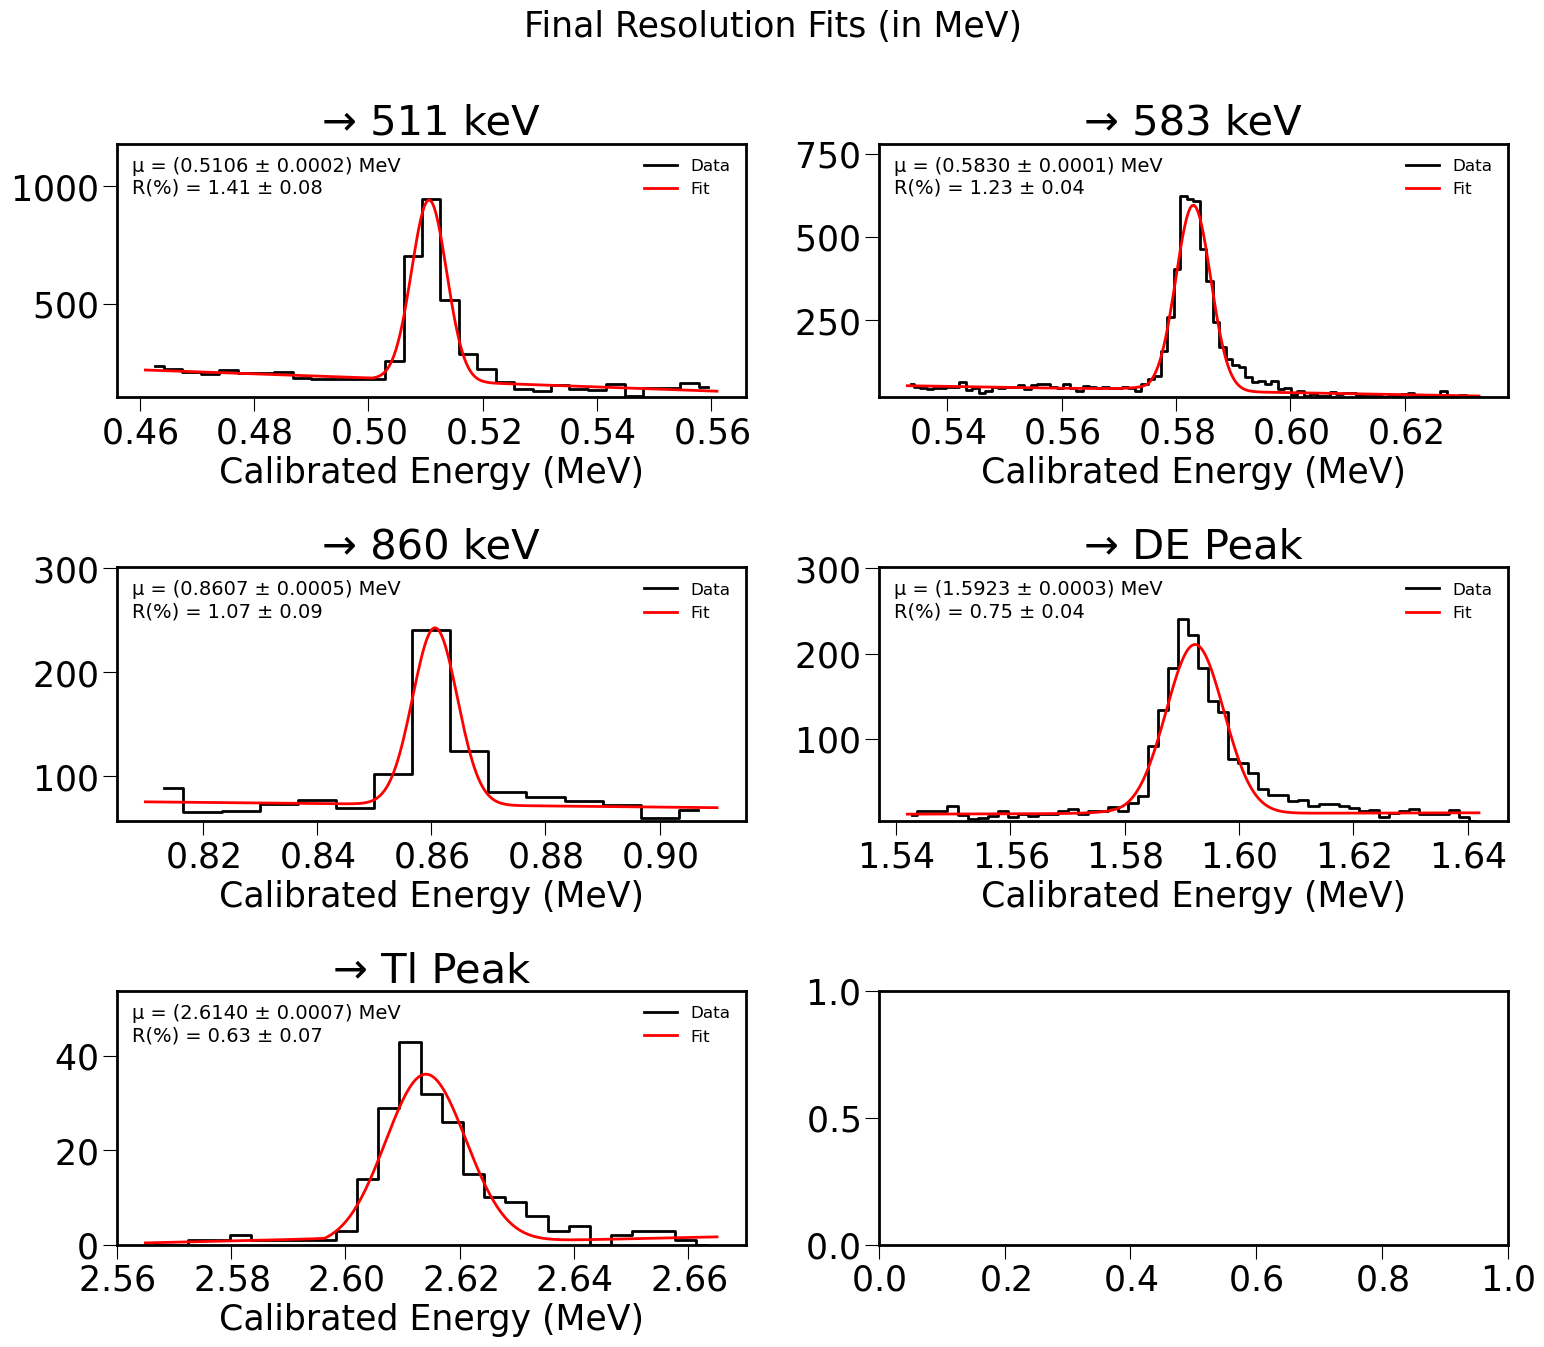

----- Final Summary -----

Calibration Results:
       m_cv     m_err      b_cv    b_err  r_value
0  0.997849  0.000164 -0.000564  0.00024      1.0


Energy Resolution Results:
      peak  resolution_(FWHM)  resolution_error
0  511 keV           1.413585          0.080325
1  583 keV           1.232865          0.038390
2  860 keV           1.070004          0.092663
3  DE Peak           0.746272          0.037717
4  Tl Peak           0.633675          0.066894


In [23]:
calibration_table, resolution_table = calibrate_and_get_resolution( event_df=FIDU_EVT_DF
                                                                  , known_peaks=KNOWN_PEAKS
                                                                  , energy_col=ENERGY_COL
                                                                  , energy_units=ENERGY_UNITS )

print("----- Final Summary -----")
print("\nCalibration Results:")
print(calibration_table)
print(f"\n{'='*50}\n")
print("Energy Resolution Results:")
print(resolution_table)